# Observations
- 20260312: all conditions are based on fast learning (1e-3) so that we can observe more convergence across runs. 
- 20260315: increased EWC strength from 1.0 to 10000.0, making EWC penalty comparable with task loss. Fixed some bugs in EWC implementation. 
- 20260317: shrank down hidden dimension to 2, hopefully it will make EWC less advantageous. Originally we had dim = 4, and with this setting we got EWC > NFZ for both L1 and L2. This seems rather weird. Therefore, I doubted whether it could be due to over-powered hidden representation, thus making it best not to move any L1 parameters but to start with new dimensions, and EWC was exactly doing this, making it better than NFZ. In this version, we make hidden dimension = 2. With more limited hidden dimensions, we anticipate to see some difference. 
- 20260319: Because we still saw quite obvious advantage of EWC for both Para and Vert, I doubted whether it is due to the model in general being too powerful. Therefore, I ran a simplistic FC Recon model and this is the result. 
- 20260417: Additionally added WeakEWC (weight 10000 -> 1000); learning rate 1e-3 -> 1e-4. 
- 20260421: Changed Parallel to tsh-tch instead of sh-ch; running different EWC weights. 
- 20260421 (1e-4): learning rate to 1e-4, EWC weight to n1 and p2. 

Comparison is between NFZ and EWC, PARA and VERT. 

L1: s-c

L2: tsh-tch / tsh-sh

`scp -r franklhtan@10.64.109.137:"/nfs/franklhtan/projects/LearnCsld2025/observe_outputs/0421_*" /mnt/data/Projects/LearnCsldLab/observations/`

Use this code to transfer from server to lab computer. 

In [1]:
# imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from itertools import product
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
def L1_condition_mapper(condition):
    if "_RCRC" in condition or "_RCCL" in condition:
        return "Recon"
    elif "_CLRC" in condition or "_CLCL" in condition:
        return "Class"

def L2_condition_mapper(condition):
    if "_RCRC" in condition or "_CLRC" in condition:
        return "Recon"
    elif "_RCCL" in condition or "_CLCL" in condition:
        return "Class"
    
def freezing_condition_mapper(condition):
    if "_FZ" in condition:
        return "Freeze"
    elif "_NFZ" in condition:
        return "NoFreeze"
    elif "_EWC" in condition:
        return "EWC"
    elif "_NPT" in condition:
        return "NoPreTrain"
    elif "_WEWC" in condition:
        return "WeakEWC"
    
def freezing_strength_mapper(condition):
    if "_EWC" in condition:
        # then get the number after EWC: p = +, n = -, number means power
        # e.g. p0 = 1e0, p3 = 1e3, n2 = 1e-2
        strength = condition.split("_EWC")[1].split("_")[0]
        if strength.startswith("p"):
            return "1e" + strength[1:]
        elif strength.startswith("n"):
            return "1e-" + strength[1:]
        else:
            return "1e" + strength
    else: 
        return "0"

def learning_rate_condition_mapper(condition):
    if "_1e5" in condition:
        return "slow"
    elif "_1e4" in condition:
        return "fast"
    elif "_1e3" in condition:
        return "superfast"
    
def L2_inventory_condition_mapper(condition):
    if "_PARA" in condition:
        return "Para"
    elif "_VERT" in condition:
        return "Vert"
    
def model_hid_size_condition_mapper(condition):
    if "_HID" in condition:
        # then get the number after HID
        hid_size = condition.split("_HID")[1].split("_")[0]
        return hid_size
    else: 
        return "4"

## Confirm: EWC strengths

In [7]:
BASE_PATH = "./observations/"

PREFIX = "0421"
L1_CONDITIONS = ["RC"]
L2_CONDITIONS = ["RC"]
FREEZING_CONDITIONS = ["EWC"]
FREEZING_STRENGTHS = ["p2", "n1"]
LEARNING_RATE_CONDITIONS = ["1e4"]  # , 
L2_INVENTORY_CONDITIONS = ["PARA", "VERT"]
HID_SIZE = ["_HID2"] # 
EVAL_METHODS = ["silhouette"]

condition_pool = [
    f"{PREFIX}_{l1}{l2}_{inv}_{freezing}{fs}_{lr}{hid}"
    for l1, l2, freezing, fs, lr, inv, hid in product(
        L1_CONDITIONS,
        L2_CONDITIONS,
        FREEZING_CONDITIONS,
        FREEZING_STRENGTHS,
        LEARNING_RATE_CONDITIONS,
        L2_INVENTORY_CONDITIONS,
        HID_SIZE,
    )
]

EPOCH_START = 10
EPOCH_END = 600
RUNS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

TRAIN_MAP = {
    "tsh_tch": "L2", "s_c": "L1", "tsh_sh": "L2"
}

integrated_df = pd.DataFrame()
for condition in condition_pool: 
    condition_path = BASE_PATH + condition + "/"
    for epoch in range(EPOCH_START, EPOCH_END + 1, 10): 
        for run in RUNS:    # currently only one run, but we want to average over multiple runs if existing
            for eval_method in EVAL_METHODS:
                file_path = condition_path + f"{eval_method}_E{epoch}_R{run}.csv"
                df = pd.read_csv(file_path)
                
                scores = df["sil_score"].tolist()
                scores_cos = df["sil_score_cos"].tolist()
                train_langs = [TRAIN_MAP[t] if t in TRAIN_MAP else "N/A" for t in df["sil_type"].tolist()]

                result_df = pd.DataFrame({
                    "L1_condition": [L1_condition_mapper(condition)] * len(scores),
                    "L2_condition": [L2_condition_mapper(condition)] * len(scores),
                    "freezing_condition": [freezing_condition_mapper(condition)] * len(scores),
                    "freezing_strength": [freezing_strength_mapper(condition)] * len(scores),
                    "learning_rate_condition": [learning_rate_condition_mapper(condition)] * len(scores),
                    "L2_inventory_condition": [L2_inventory_condition_mapper(condition)] * len(scores),
                    "hid_size_condition": [model_hid_size_condition_mapper(condition)] * len(scores),
                    "contrast_pair": df["sil_type"].tolist(),
                    "train_lang": train_langs,
                    "eval_method": [eval_method] * len(scores),
                    "sil_score": scores, 
                    "sil_score_cos": scores_cos,
                    "run": [run] * len(scores),
                    "epoch": [epoch] * len(scores)})
                integrated_df = pd.concat([integrated_df, result_df], ignore_index=True)
    

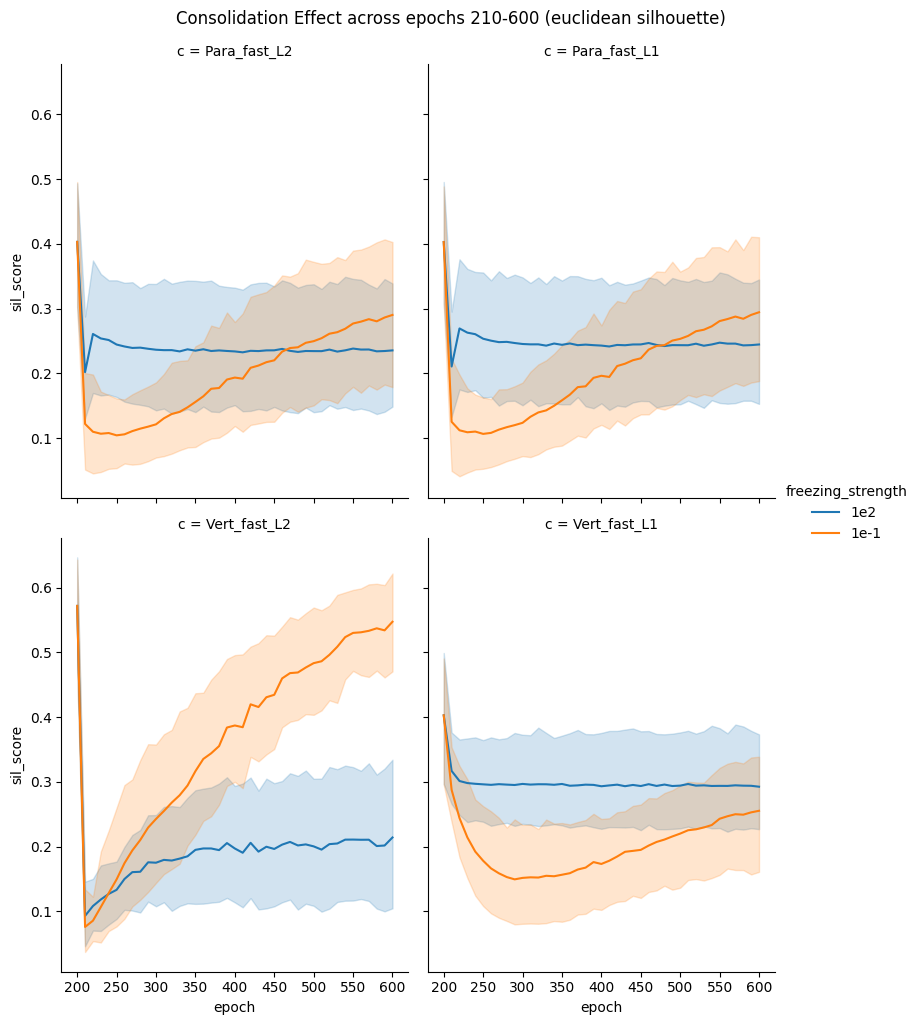

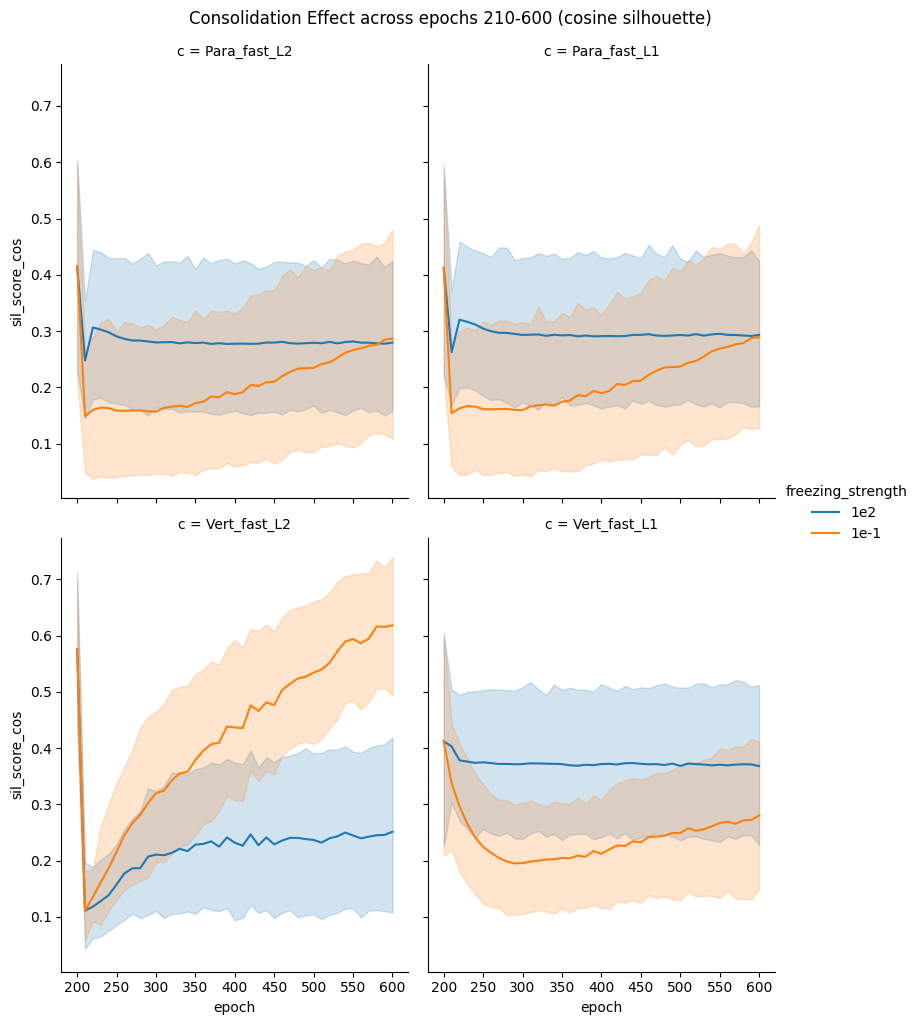

In [8]:
df = integrated_df.copy()
df["combined_inv_lr"] = df["L2_inventory_condition"] + "_" + df["learning_rate_condition"]
df = df[df["train_lang"].isin(["L1", "L2"])]
# df = df[df["learning_rate_condition"] == "fast"]
df = df[df["epoch"].isin(range(200, 601, 10))]
df["c"] = df["L2_inventory_condition"] + "_" + df["learning_rate_condition"] + "_" + df["train_lang"]

g = sns.relplot(
    data=df,
    x="epoch",
    y="sil_score",
    hue="freezing_strength",
    col="c",
    col_wrap=2,
    kind="line",
    errorbar=("ci", 95),
    aspect=0.8
)

g.fig.suptitle("Consolidation Effect across epochs 210-600 (euclidean silhouette)", y=1.02)
for ax in g.axes.flatten():
    ax.set_xticks(range(200, 601, 50))

g = sns.relplot(
    data=df,
    x="epoch",
    y="sil_score_cos",
    hue="freezing_strength",
    col="c",
    col_wrap=2,
    kind="line",
    errorbar=("ci", 95),
    aspect=0.8
)

g.fig.suptitle("Consolidation Effect across epochs 210-600 (cosine silhouette)", y=1.02)
for ax in g.axes.flatten():
    ax.set_xticks(range(200, 601, 50))

This plot is consistent with our previous observations, with the only difference being that, because EWC is not as large, and learning rate is slower, the learning process is now more obvious. Yet we still observe that learger EWC weight (i.e. more consolidation constraint) will lead to more lower learning efficiency in distributional learning of new feature. 

## Learning Rate: 1e3 vs 1e4

In [5]:
BASE_PATH = "./observations/"

PREFIX = "0317"
L1_CONDITIONS = ["RC"]
L2_CONDITIONS = ["RC"]
FREEZING_CONDITIONS = ["NFZ"]
LEARNING_RATE_CONDITIONS = ["1e3", "1e4"]  # , 
L2_INVENTORY_CONDITIONS = ["PARA", "VERT"]
HID_SIZE = ["_HID2"] # 
EVAL_METHODS = ["silhouette"]

condition_pool = [
    f"{PREFIX}_{l1}{l2}_{inv}_{freezing}_{lr}{hid}"
    for l1, l2, freezing, lr, inv, hid in product(
        L1_CONDITIONS,
        L2_CONDITIONS,
        FREEZING_CONDITIONS,
        LEARNING_RATE_CONDITIONS,
        L2_INVENTORY_CONDITIONS,
        HID_SIZE,
    )
]

EPOCH_START = 10
EPOCH_END = 600
RUNS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

TRAIN_MAP = {
    "sh_ch": "L2", "s_c": "L1", "tsh_sh": "L2"
}

integrated_df = pd.DataFrame()
for condition in condition_pool: 
    condition_path = BASE_PATH + condition + "/"
    for epoch in range(EPOCH_START, EPOCH_END + 1, 10): 
        for run in RUNS:    # currently only one run, but we want to average over multiple runs if existing
            for eval_method in EVAL_METHODS:
                file_path = condition_path + f"{eval_method}_E{epoch}_R{run}.csv"
                df = pd.read_csv(file_path)
                
                scores = df["sil_score"].tolist()
                scores_cos = df["sil_score_cos"].tolist()
                train_langs = [TRAIN_MAP[t] if t in TRAIN_MAP else "N/A" for t in df["sil_type"].tolist()]

                result_df = pd.DataFrame({
                    "L1_condition": [L1_condition_mapper(condition)] * len(scores),
                    "L2_condition": [L2_condition_mapper(condition)] * len(scores),
                    "freezing_condition": [freezing_condition_mapper(condition)] * len(scores),
                    "learning_rate_condition": [learning_rate_condition_mapper(condition)] * len(scores),
                    "L2_inventory_condition": [L2_inventory_condition_mapper(condition)] * len(scores),
                    "hid_size_condition": [model_hid_size_condition_mapper(condition)] * len(scores),
                    "contrast_pair": df["sil_type"].tolist(),
                    "train_lang": train_langs,
                    "eval_method": [eval_method] * len(scores),
                    "sil_score": scores, 
                    "sil_score_cos": scores_cos,
                    "run": [run] * len(scores),
                    "epoch": [epoch] * len(scores)})
                integrated_df = pd.concat([integrated_df, result_df], ignore_index=True)
    

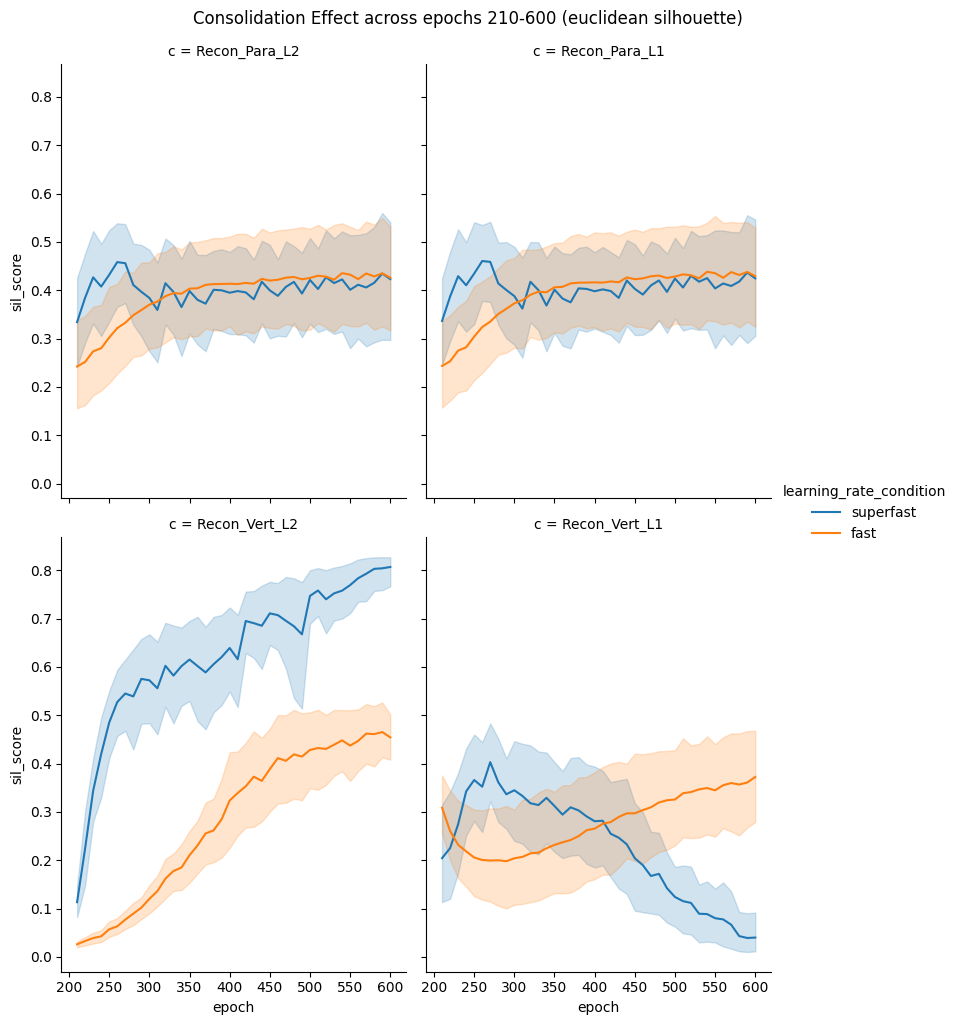

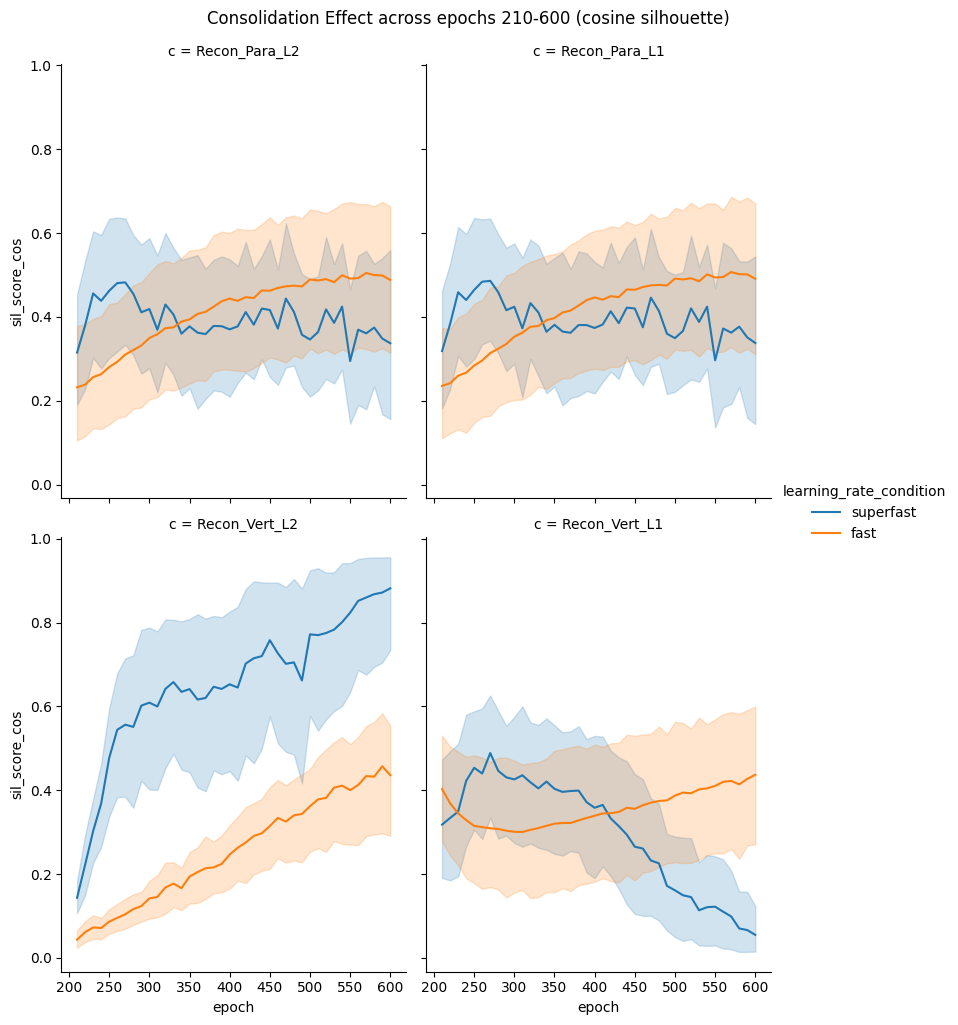

In [6]:
df = integrated_df.copy()
df["combined_inv_lr"] = df["L2_inventory_condition"] + "_" + df["learning_rate_condition"]
df = df[df["train_lang"].isin(["L1", "L2"])]
# df = df[df["learning_rate_condition"] == "fast"]
df = df[df["epoch"].isin(range(210, 601, 10))]
df["c"] = df["L2_condition"] + "_" + df["L2_inventory_condition"] + "_" + df["train_lang"]

g = sns.relplot(
    data=df,
    x="epoch",
    y="sil_score",
    hue="learning_rate_condition",
    col="c",
    col_wrap=2,
    kind="line",
    errorbar=("ci", 95),
    aspect=0.8
)

g.fig.suptitle("Consolidation Effect across epochs 210-600 (euclidean silhouette)", y=1.02)
for ax in g.axes.flatten():
    ax.set_xticks(range(200, 601, 50))

g = sns.relplot(
    data=df,
    x="epoch",
    y="sil_score_cos",
    hue="learning_rate_condition",
    col="c",
    col_wrap=2,
    kind="line",
    errorbar=("ci", 95),
    aspect=0.8
)

g.fig.suptitle("Consolidation Effect across epochs 210-600 (cosine silhouette)", y=1.02)
for ax in g.axes.flatten():
    ax.set_xticks(range(200, 601, 50))

## NFZ:EWC ~ RC:CL

In [7]:
BASE_PATH = "./observations/"

PREFIX = "0317"
L1_CONDITIONS = ["RC"]
L2_CONDITIONS = ["RC", "CL"]
FREEZING_CONDITIONS = ["NFZ", "EWC"]
LEARNING_RATE_CONDITIONS = ["1e3"]  # , 
L2_INVENTORY_CONDITIONS = ["PARA", "VERT"]
HID_SIZE = ["_HID2"] # 
EVAL_METHODS = ["silhouette"]

condition_pool = [
    f"{PREFIX}_{l1}{l2}_{inv}_{freezing}_{lr}{hid}"
    for l1, l2, freezing, lr, inv, hid in product(
        L1_CONDITIONS,
        L2_CONDITIONS,
        FREEZING_CONDITIONS,
        LEARNING_RATE_CONDITIONS,
        L2_INVENTORY_CONDITIONS,
        HID_SIZE,
    )
]

EPOCH_START = 10
EPOCH_END = 600
RUNS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

TRAIN_MAP = {
    "sh_ch": "L2", "s_c": "L1", "tsh_sh": "L2"
}

integrated_df = pd.DataFrame()
for condition in condition_pool: 
    condition_path = BASE_PATH + condition + "/"
    for epoch in range(EPOCH_START, EPOCH_END + 1, 10): 
        for run in RUNS:    # currently only one run, but we want to average over multiple runs if existing
            for eval_method in EVAL_METHODS:
                file_path = condition_path + f"{eval_method}_E{epoch}_R{run}.csv"
                df = pd.read_csv(file_path)
                
                scores = df["sil_score"].tolist()
                scores_cos = df["sil_score_cos"].tolist()
                train_langs = [TRAIN_MAP[t] if t in TRAIN_MAP else "N/A" for t in df["sil_type"].tolist()]

                result_df = pd.DataFrame({
                    "L1_condition": [L1_condition_mapper(condition)] * len(scores),
                    "L2_condition": [L2_condition_mapper(condition)] * len(scores),
                    "freezing_condition": [freezing_condition_mapper(condition)] * len(scores),
                    "learning_rate_condition": [learning_rate_condition_mapper(condition)] * len(scores),
                    "L2_inventory_condition": [L2_inventory_condition_mapper(condition)] * len(scores),
                    "hid_size_condition": [model_hid_size_condition_mapper(condition)] * len(scores),
                    "contrast_pair": df["sil_type"].tolist(),
                    "train_lang": train_langs,
                    "eval_method": [eval_method] * len(scores),
                    "sil_score": scores, 
                    "sil_score_cos": scores_cos,
                    "run": [run] * len(scores),
                    "epoch": [epoch] * len(scores)})
                integrated_df = pd.concat([integrated_df, result_df], ignore_index=True)
    

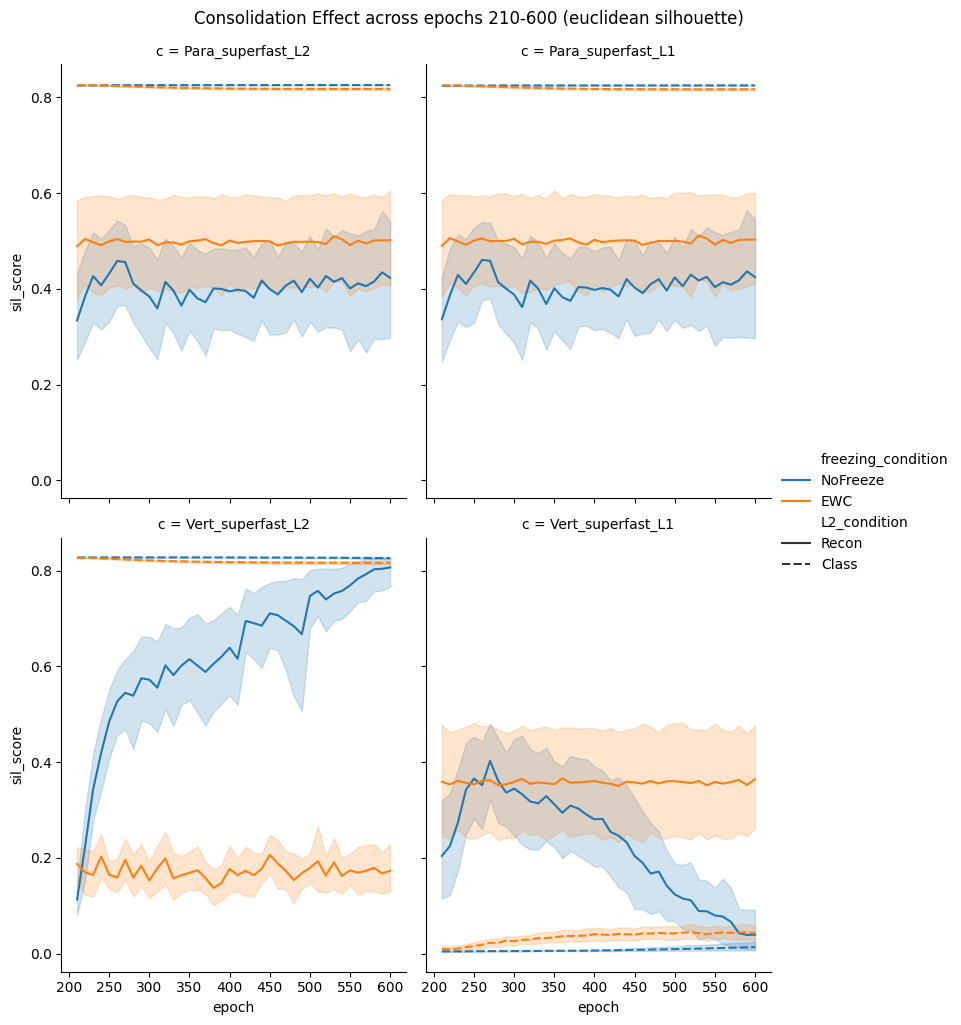

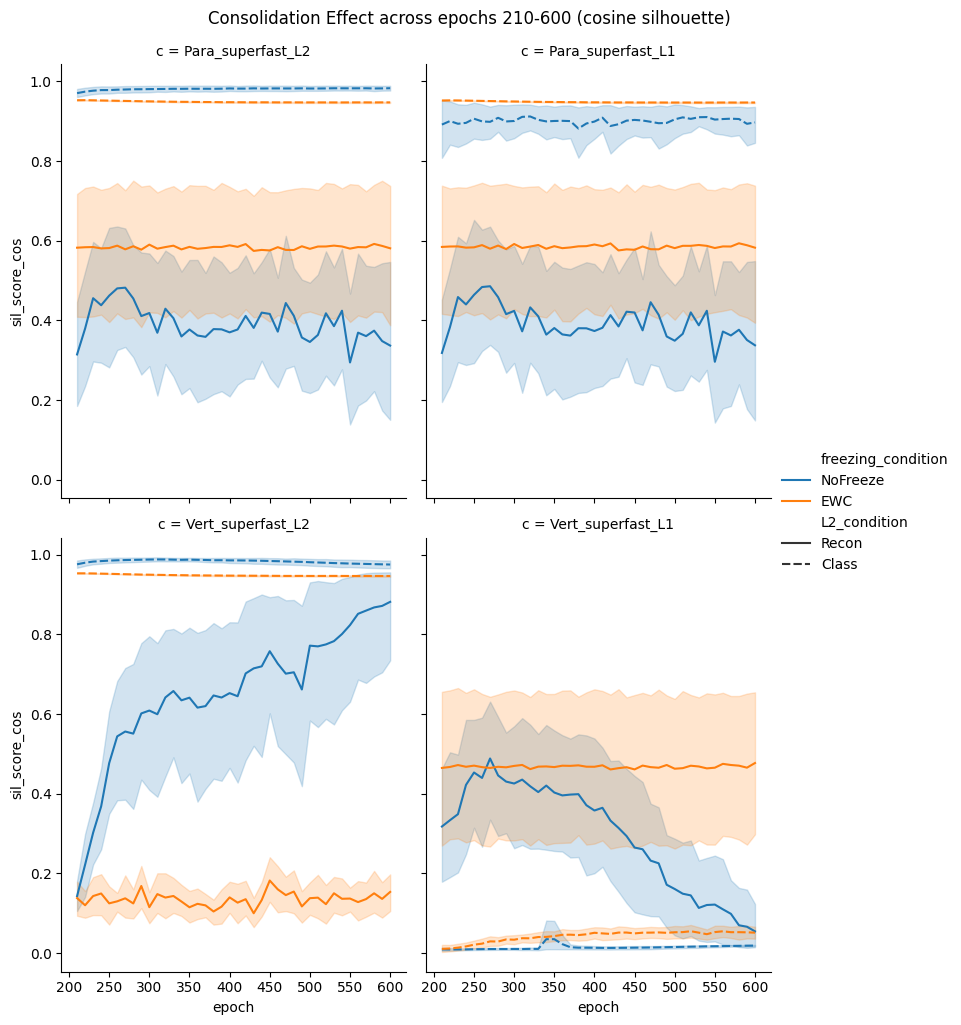

In [8]:
df = integrated_df.copy()
df["combined_inv_lr"] = df["L2_inventory_condition"] + "_" + df["learning_rate_condition"]
df = df[df["train_lang"].isin(["L1", "L2"])]
# df = df[df["learning_rate_condition"] == "fast"]
df = df[df["epoch"].isin(range(210, 601, 10))]
df["c"] = df["L2_inventory_condition"] + "_" + df["learning_rate_condition"] + "_" + df["train_lang"]

g = sns.relplot(
    data=df,
    x="epoch",
    y="sil_score",
    hue="freezing_condition",
    style="L2_condition", 
    col="c",
    col_wrap=2,
    kind="line",
    errorbar=("ci", 95),
    aspect=0.8
)

g.fig.suptitle("Consolidation Effect across epochs 210-600 (euclidean silhouette)", y=1.02)
for ax in g.axes.flatten():
    ax.set_xticks(range(200, 601, 50))

g = sns.relplot(
    data=df,
    x="epoch",
    y="sil_score_cos",
    hue="freezing_condition",
    style="L2_condition", 
    col="c",
    col_wrap=2,
    kind="line",
    errorbar=("ci", 95),
    aspect=0.8
)

g.fig.suptitle("Consolidation Effect across epochs 210-600 (cosine silhouette)", y=1.02)
for ax in g.axes.flatten():
    ax.set_xticks(range(200, 601, 50))